# ADS 2026 - Assignment 4, Part 1: ML Pipelines

This notebook solves **Part 1 only** of Assignment 4. The goal is to build a clean and reproducible machine-learning pipeline for the loan-status binary classification dataset.

- Dataset: `classification_DATA.csv`
- Target column: `loan_status`
- Problem type: binary classification
- Main focus: pandas cleaning pipes, sklearn preprocessing pipelines, imputers inside pipelines, an end-to-end classifier pipeline, and model persistence

The target is imbalanced, with many more class `0` rows than class `1` rows, so the evaluation section uses more than accuracy.


## 1. Imports and Configuration



In [1]:
from pathlib import Path
import io
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.compose import ColumnTransformer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TARGET_COL = "loan_status"

BASE_DIR = Path.cwd()
DATA_CANDIDATES = [Path("classification_DATA.csv"), Path("data") / "classification_DATA.csv"]
MODEL_DIR = Path("models")
OUTPUT_DIR = Path("outputs")
REPORT_DIR = Path("reports")
MODEL_PATH = MODEL_DIR / "loan_status_pipeline.joblib"

OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

print(f"Working directory: {BASE_DIR}")
print(f"Random state: {RANDOM_STATE}")


Working directory: D:\SHARIF\TERM7\DATA\HW4\PART1
Random state: 42


## 2. Data Loading



In [2]:
def find_data_path(candidates):
    """Return the first existing data path from a list of relative candidates."""
    for path in candidates:
        if path.exists():
            return path
    candidate_text = ", ".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find classification data in: {candidate_text}")


def load_dataset(path):
    """Load the CSV without modifying the original file."""
    return pd.read_csv(path)


DATA_PATH = find_data_path(DATA_CANDIDATES)
raw_df = load_dataset(DATA_PATH)

print(f"Loaded data from: {DATA_PATH}")
display(raw_df.head())
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]:,} columns")


Loaded data from: classification_DATA.csv


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_Master,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_VENTURE,log_person_income,log_loan_amnt,whole_loan_percent_income,loan_credit,interest_burden,employment_experience_ratio,interest_per_credit_score,default_interest_interaction,high_loan_burden,high_interest_rate,annual_interest_amount,young_applicant,low_income_applicant,high_income_applicant,short_credit_history,loan_status
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,0,0,0,1,0,0,0,0,0,0,0,0,11.183713,10.463132,0.082796,46.448504,7.8498,0.000000,0.028556,0.00,1,1,5607.00,1,0,0,0,1
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,0,0,0,0,0,1,0,1,0,0,0,9.415971,6.908755,0.009884,4.981729,0.8912,0.000000,0.022103,11.14,0,0,111.40,1,1,0,1,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,0,0,0,0,1,0,0,0,0,0,1,0,9.428592,8.612685,0.061332,38.945952,5.6628,0.428571,0.020268,0.00,1,0,707.85,0,1,0,0,1
3,23.0,0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,0,1,0,0,0,0,0,0,0,0,1,0,11.286702,10.463132,0.071226,48.077659,6.7012,0.000000,0.022563,0.00,1,1,5330.50,1,0,0,1,1
4,24.0,1,66135.0,1,35000.0,14.27,0.53,4.0,586,0,0,0,0,1,0,0,0,0,0,0,1,0,11.099469,10.463132,0.080812,47.355818,7.5631,0.166667,0.024352,0.00,1,1,4994.50,1,0,0,0,1


Shape: 44,993 rows x 38 columns


## 3. Quick Inspection

Before building any pipeline, we check basic data quality: columns, dtypes, missing values, duplicates, and target balance.

This confirms the modeling assumptions and highlights why accuracy alone will not be enough for evaluation.


Column names:
['person_age', 'person_gender', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'person_education_Associate', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_Master', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_VENTURE', 'log_person_income', 'log_loan_amnt', 'whole_loan_percent_income', 'loan_credit', 'interest_burden', 'employment_experience_ratio', 'interest_per_credit_score', 'default_interest_interaction', 'high_loan_burden', 'high_interest_rate', 'annual_interest_amount', 'young_applicant', 'low_income_applicant', 'high_income_applicant', 'short_credit_history', 'loan_status']

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44993 

,missing_count,missing_percent
person_age,0,0.0
person_gender,0,0.0
person_income,0,0.0
person_emp_exp,0,0.0
loan_amnt,0,0.0
loan_int_rate,0,0.0
loan_percent_income,0,0.0
cb_person_cred_hist_length,0,0.0
credit_score,0,0.0
previous_loan_defaults_on_file,0,0.0


Target distribution:


,count,percent
loan_status,,
0,34993,77.77432
1,10000,22.22568


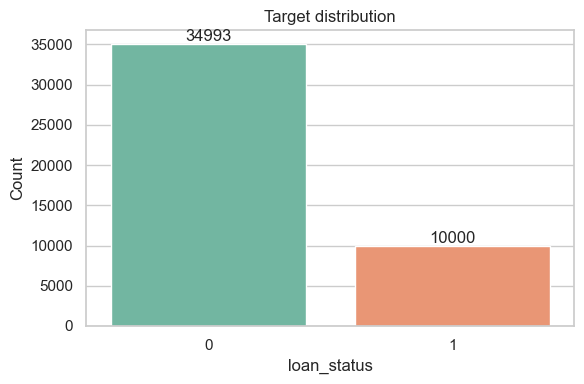

In [3]:
if TARGET_COL not in raw_df.columns:
    raise ValueError(f"Target column {TARGET_COL!r} was not found in the dataset.")

print("Column names:")
print(list(raw_df.columns))

print("\nDataFrame info:")
info_buffer = io.StringIO()
raw_df.info(buf=info_buffer)
print(info_buffer.getvalue())

missing_table = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_percent": raw_df.isna().mean().mul(100),
}).sort_values(["missing_count", "missing_percent"], ascending=False)

duplicate_count = int(raw_df.duplicated().sum())

target_distribution = raw_df[TARGET_COL].value_counts(dropna=False).sort_index().to_frame("count")
target_distribution["percent"] = target_distribution["count"].div(len(raw_df)).mul(100)

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Total missing values: {int(raw_df.isna().sum().sum()):,}")
print("\nMissing value table:")
display(missing_table)

print("Target distribution:")
display(target_distribution)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=raw_df, x=TARGET_COL, hue=TARGET_COL, palette="Set2", legend=False, ax=ax)
ax.set_title("Target distribution")
ax.set_xlabel("loan_status")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Dataset Notes

The dataset has already been prepared in previous assignment work, so preprocessing must respect the existing encoding.

All columns are numeric in this CSV. Several columns are already binary or one-hot indicators, such as education, home ownership, and loan intent columns. We should not one-hot encode those existing indicators again. The preprocessing code still includes a raw categorical branch so a future dataset version with object/category columns can be handled safely inside the pipeline.


## 5. Pandas Data Cleaning Pipeline

pandas `.pipe` makes data cleaning readable and testable by passing the DataFrame through small functions.

Critical checks raise clear errors, while non-critical range concerns are reported without silently dropping records or changing the original CSV.


In [4]:
KNOWN_CONTINUOUS_COLUMNS = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score",
    "log_person_income",
    "log_loan_amnt",
    "whole_loan_percent_income",
    "loan_credit",
    "interest_burden",
    "employment_experience_ratio",
    "interest_per_credit_score",
    "default_interest_interaction",
    "annual_interest_amount",
]

KNOWN_BINARY_COLUMNS = [
    "person_gender",
    "previous_loan_defaults_on_file",
    "person_education_Associate",
    "person_education_Bachelor",
    "person_education_Doctorate",
    "person_education_Master",
    "person_home_ownership_MORTGAGE",
    "person_home_ownership_OTHER",
    "person_home_ownership_OWN",
    "loan_intent_DEBTCONSOLIDATION",
    "loan_intent_EDUCATION",
    "loan_intent_HOMEIMPROVEMENT",
    "loan_intent_MEDICAL",
    "loan_intent_VENTURE",
    "high_loan_burden",
    "high_interest_rate",
    "young_applicant",
    "low_income_applicant",
    "high_income_applicant",
    "short_credit_history",
]


def standardize_column_names(df):
    cleaned = df.copy()
    cleaned.columns = (
        cleaned.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return cleaned


def validate_required_columns(df, required_columns):
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return df


def validate_target_column(df, target_col=TARGET_COL):
    if df[target_col].isna().any():
        raise ValueError(f"Target column {target_col!r} contains missing values.")
    observed_values = set(df[target_col].dropna().unique())
    if not observed_values.issubset({0, 1, 0.0, 1.0}):
        raise ValueError(f"Target column must be binary 0/1. Observed values: {observed_values}")
    return df


def report_basic_quality(df):
    summary = pd.Series({
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "numeric_columns": int(df.select_dtypes(include=np.number).shape[1]),
        "non_numeric_columns": int(df.select_dtypes(exclude=np.number).shape[1]),
    }).to_frame("value")
    display(summary)
    return df


def remove_duplicate_rows(df):
    before = len(df)
    cleaned = df.drop_duplicates().copy()
    removed = before - len(cleaned)
    print(f"Duplicate rows removed: {removed:,}")
    return cleaned


def validate_numeric_ranges(df):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    suspicious_messages = []

    non_negative_cols = [
        col for col in numeric_cols
        if col != TARGET_COL and not col.endswith("_interaction")
    ]
    for col in non_negative_cols:
        if (df[col] < 0).any():
            suspicious_messages.append(f"{col}: contains negative values")

    if "person_age" in df.columns and ((df["person_age"] < 18) | (df["person_age"] > 100)).any():
        suspicious_messages.append("person_age: values outside expected adult range 18-100")

    if "loan_percent_income" in df.columns and (df["loan_percent_income"] > 1.5).any():
        suspicious_messages.append("loan_percent_income: some values are above 1.5")

    if suspicious_messages:
        print("Range warnings. No rows were dropped automatically:")
        for message in suspicious_messages:
            print(f"- {message}")
    else:
        print("Range check passed with no suspicious values from the configured checks.")
    return df


def validate_binary_columns(df, binary_cols):
    checked_columns = [column for column in binary_cols if column in df.columns]
    invalid = {}
    for column in checked_columns:
        observed = set(df[column].dropna().unique())
        if not observed.issubset({0, 1, 0.0, 1.0}):
            invalid[column] = sorted(observed)
    if invalid:
        raise ValueError(f"Binary columns contain values outside 0/1: {invalid}")
    print(f"Validated {len(checked_columns)} binary/already-encoded columns.")
    return df


def enforce_numeric_dtypes(df):
    cleaned = df.copy()
    for column in cleaned.columns:
        cleaned[column] = pd.to_numeric(cleaned[column], errors="raise")
    return cleaned


def final_cleaning_summary(df):
    summary = pd.Series({
        "final_rows": df.shape[0],
        "final_columns": df.shape[1],
        "final_missing_values": int(df.isna().sum().sum()),
        "final_duplicate_rows": int(df.duplicated().sum()),
    }).to_frame("value")
    display(summary)
    return df


### Run the pandas `.pipe` Chain

Now we apply the cleaning functions in a single readable chain.
The result is a validated DataFrame ready for splitting, and the original `raw_df` remains unchanged.


In [5]:
required_columns = [TARGET_COL]
binary_indicator_cols = [column for column in KNOWN_BINARY_COLUMNS if column in raw_df.columns]

cleaned_df = (
    raw_df
    .pipe(standardize_column_names)
    .pipe(validate_required_columns, required_columns=required_columns)
    .pipe(validate_target_column, target_col=TARGET_COL)
    .pipe(report_basic_quality)
    .pipe(remove_duplicate_rows)
    .pipe(enforce_numeric_dtypes)
    .pipe(validate_numeric_ranges)
    .pipe(validate_binary_columns, binary_cols=binary_indicator_cols)
    .pipe(final_cleaning_summary)
)

print(f"Original shape: {raw_df.shape}")
print(f"Cleaned shape:  {cleaned_df.shape}")
display(cleaned_df.head())


,value
rows,44993
columns,38
missing_values,0
duplicate_rows,0
numeric_columns,38
non_numeric_columns,0


Duplicate rows removed: 0
Range check passed with no suspicious values from the configured checks.
Validated 20 binary/already-encoded columns.


,value
final_rows,44993
final_columns,38
final_missing_values,0
final_duplicate_rows,0


Original shape: (44993, 38)
Cleaned shape:  (44993, 38)


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_Master,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_VENTURE,log_person_income,log_loan_amnt,whole_loan_percent_income,loan_credit,interest_burden,employment_experience_ratio,interest_per_credit_score,default_interest_interaction,high_loan_burden,high_interest_rate,annual_interest_amount,young_applicant,low_income_applicant,high_income_applicant,short_credit_history,loan_status
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,0,0,0,1,0,0,0,0,0,0,0,0,11.183713,10.463132,0.082796,46.448504,7.8498,0.000000,0.028556,0.00,1,1,5607.00,1,0,0,0,1
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,0,0,0,0,0,1,0,1,0,0,0,9.415971,6.908755,0.009884,4.981729,0.8912,0.000000,0.022103,11.14,0,0,111.40,1,1,0,1,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,0,0,0,0,1,0,0,0,0,0,1,0,9.428592,8.612685,0.061332,38.945952,5.6628,0.428571,0.020268,0.00,1,0,707.85,0,1,0,0,1
3,23.0,0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,0,1,0,0,0,0,0,0,0,0,1,0,11.286702,10.463132,0.071226,48.077659,6.7012,0.000000,0.022563,0.00,1,1,5330.50,1,0,0,1,1
4,24.0,1,66135.0,1,35000.0,14.27,0.53,4.0,586,0,0,0,0,1,0,0,0,0,0,0,1,0,11.099469,10.463132,0.080812,47.355818,7.5631,0.166667,0.024352,0.00,1,1,4994.50,1,0,0,0,1


## 6. Feature/Target Split

The model must learn from features `X` and predict the target `y`. A stratified split preserves the imbalanced class ratio in both train and test sets.
The test set remains untouched until final evaluation, making the performance estimate more honest.


In [6]:
X = cleaned_df.drop(columns=[TARGET_COL])
y = cleaned_df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)


def class_distribution(series, split_name):
    counts = series.value_counts().sort_index().to_frame("count")
    counts["percent"] = counts["count"].div(len(series)).mul(100)
    counts.insert(0, "split", split_name)
    return counts


split_distribution = pd.concat([
    class_distribution(y_train, "train"),
    class_distribution(y_test, "test"),
])

display(split_distribution)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")


,split,count,percent
loan_status,,,
0,train,27994,77.774073
1,train,8000,22.225927
0,test,6999,77.775308
1,test,2000,22.224692


X_train: (35994, 37), X_test: (8999, 37)


## 7. Feature Group Detection

 Different feature types need different preprocessing. Continuous numeric features should be imputed and scaled, binary indicators should be imputed but not one-hot encoded again, and future raw categorical columns should be encoded safely.


In [7]:
def detect_feature_groups(X_data):
    raw_categorical_cols = X_data.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    numeric_cols = X_data.select_dtypes(include=np.number).columns.tolist()

    known_binary_present = [column for column in KNOWN_BINARY_COLUMNS if column in X_data.columns]
    dynamic_binary_cols = []
    for column in numeric_cols:
        observed = set(X_data[column].dropna().unique())
        if len(observed) <= 2 and observed.issubset({0, 1, 0.0, 1.0}):
            dynamic_binary_cols.append(column)

    binary_cols = sorted(set(known_binary_present).union(dynamic_binary_cols))
    continuous_cols = [column for column in numeric_cols if column not in binary_cols]

    return {
        "continuous": continuous_cols,
        "binary": binary_cols,
        "categorical": raw_categorical_cols,
    }


feature_groups = detect_feature_groups(X_train)
continuous_numeric_cols = feature_groups["continuous"]
binary_cols = feature_groups["binary"]
raw_categorical_cols = feature_groups["categorical"]

feature_group_summary = pd.DataFrame([
    {
        "group": group_name,
        "n_features": len(columns),
        "features": ", ".join(columns) if columns else "None",
    }
    for group_name, columns in feature_groups.items()
])

display(feature_group_summary)

print(f"Continuous numeric features: {len(continuous_numeric_cols)}")
print(f"Binary/already-encoded features: {len(binary_cols)}")
print(f"Raw categorical features: {len(raw_categorical_cols)}")


,group,n_features,features
0,continuous,17,"person_age, person_income, person_emp_exp, loa..."
1,binary,20,"high_income_applicant, high_interest_rate, hig..."
2,categorical,0,None


Continuous numeric features: 17
Binary/already-encoded features: 20
Raw categorical features: 0


## 8. Scikit-learn Preprocessing Pipeline

Preprocessing must be fitted only on training data. Putting imputers, scaling, and encoding inside a `ColumnTransformer` prevents leakage from the test set.
The same transformation logic can be used during training, evaluation, saving, loading, and future prediction.


In [8]:
def make_one_hot_encoder():
    """Create a OneHotEncoder compatible with both older and newer sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(continuous_cols, binary_indicator_cols, categorical_cols, continuous_imputer):
    transformers = []

    if continuous_cols:
        continuous_pipeline = Pipeline(steps=[
            ("imputer", continuous_imputer),
            ("scaler", StandardScaler()),
        ])
        transformers.append(("continuous", continuous_pipeline, continuous_cols))

    if binary_indicator_cols:
        binary_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ])
        transformers.append(("binary", binary_pipeline, binary_indicator_cols))

    if categorical_cols:
        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ])
        transformers.append(("categorical", categorical_pipeline, categorical_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_classifier(max_iter=1000):
    return LogisticRegression(
        max_iter=max_iter,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    )


preprocessor = build_preprocessor(
    continuous_numeric_cols,
    binary_cols,
    raw_categorical_cols,
    continuous_imputer=SimpleImputer(strategy="median"),
)

print(preprocessor)


ColumnTransformer(transformers=[('continuous',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['person_age', 'person_income',
                                  'person_emp_exp', 'loan_amnt',
                                  'loan_int_rate', 'loan_percent_income',
                                  'cb_person_cred_hist_length', 'credit_score',
                                  'log_person_income', 'log_loan_amnt',
                                  'whole_loan_percent_income', 'loan_cr...
                                  'low_income_applicant',
                                  'person_education_Associate',
                                  'person_education_Bachelor',
                                  'person_education_Doctorate',
                                  'person_educ

## 9. Missing Data Handling and Imputation Comparison

The CSV currently has no missing values, but the assignment requires comparing imputation strategies. To make the comparison meaningful, we inject 5 percent missingness into selected continuous columns on copies of training/validation data only.


Original training missing values before experiment: 0
Original test missing values before experiment: 0
Experiment train shape: (6000, 37)
Experiment validation shape: (2000, 37)
Columns with artificial missingness:
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


,train_missing_count,valid_missing_count
person_age,295,111
person_income,308,110
person_emp_exp,284,109
loan_amnt,314,105
loan_int_rate,308,80
loan_percent_income,309,93
cb_person_cred_hist_length,284,84
credit_score,287,100


,strategy,accuracy,precision,recall,f1,f1_macro,f1_weighted,roc_auc,pr_auc
0,iterative,0.8585,0.622527,0.921171,0.742961,0.822671,0.866989,0.953457,0.851122
1,median,0.8560,0.619632,0.909910,0.737226,0.819026,0.864507,0.952225,0.850636
2,mean,0.8570,0.621538,0.909910,0.738574,0.820078,0.865395,0.952085,0.849128
3,knn,0.8535,0.614568,0.912162,0.734361,0.816611,0.862342,0.952166,0.848070


Best strategy by PR-AUC: iterative


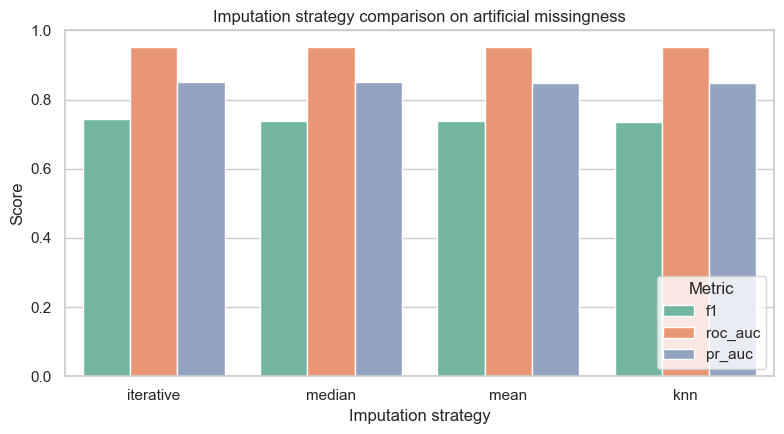

In [9]:
print(f"Original training missing values before experiment: {int(X_train.isna().sum().sum()):,}")
print(f"Original test missing values before experiment: {int(X_test.isna().sum().sum()):,}")

X_train_inner, X_valid_inner, y_train_inner, y_valid_inner = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train,
)


def stratified_limit(X_data, y_data, max_rows, random_state):
    if len(X_data) <= max_rows:
        return X_data.copy(), y_data.copy()
    _, X_sample, _, y_sample = train_test_split(
        X_data,
        y_data,
        test_size=max_rows,
        random_state=random_state,
        stratify=y_data,
    )
    return X_sample.copy(), y_sample.copy()


X_train_exp, y_train_exp = stratified_limit(X_train_inner, y_train_inner, 6000, RANDOM_STATE)
X_valid_exp, y_valid_exp = stratified_limit(X_valid_inner, y_valid_inner, 2000, RANDOM_STATE)

missing_experiment_cols = continuous_numeric_cols[:8]


def inject_missing_values(X_data, columns, missing_rate=0.05, random_state=RANDOM_STATE):
    X_missing = X_data.copy()
    rng = np.random.default_rng(random_state)
    for column in columns:
        mask = rng.random(X_missing.shape[0]) < missing_rate
        X_missing.loc[X_missing.index[mask], column] = np.nan
    return X_missing


X_train_missing = inject_missing_values(
    X_train_exp,
    missing_experiment_cols,
    missing_rate=0.05,
    random_state=RANDOM_STATE,
)
X_valid_missing = inject_missing_values(
    X_valid_exp,
    missing_experiment_cols,
    missing_rate=0.05,
    random_state=RANDOM_STATE + 1,
)

print(f"Experiment train shape: {X_train_missing.shape}")
print(f"Experiment validation shape: {X_valid_missing.shape}")
print("Columns with artificial missingness:")
print(missing_experiment_cols)

artificial_missing_summary = pd.DataFrame({
    "train_missing_count": X_train_missing[missing_experiment_cols].isna().sum(),
    "valid_missing_count": X_valid_missing[missing_experiment_cols].isna().sum(),
})
display(artificial_missing_summary)


def collect_binary_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


imputer_strategies = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "knn": KNNImputer(n_neighbors=5),
    "iterative": IterativeImputer(random_state=RANDOM_STATE, max_iter=10),
}

imputation_rows = []
for strategy_name, imputer in imputer_strategies.items():
    experiment_preprocessor = build_preprocessor(
        continuous_numeric_cols,
        binary_cols,
        raw_categorical_cols,
        continuous_imputer=imputer,
    )
    experiment_pipeline = Pipeline(steps=[
        ("preprocessor", experiment_preprocessor),
        ("classifier", make_classifier(max_iter=1000)),
    ])
    experiment_pipeline.fit(X_train_missing, y_train_exp)
    valid_pred = experiment_pipeline.predict(X_valid_missing)
    valid_score = experiment_pipeline.predict_proba(X_valid_missing)[:, 1]
    row = {"strategy": strategy_name}
    row.update(collect_binary_metrics(y_valid_exp, valid_pred, valid_score))
    imputation_rows.append(row)

imputation_results_df = (
    pd.DataFrame(imputation_rows)
    .sort_values(["pr_auc", "f1"], ascending=False)
    .reset_index(drop=True)
)
best_imputation_strategy = imputation_results_df.loc[0, "strategy"]
imputation_results_df.to_csv(OUTPUT_DIR / "imputation_strategy_results.csv", index=False)

display(imputation_results_df)
print(f"Best strategy by PR-AUC: {best_imputation_strategy}")

plot_metrics = ["f1", "roc_auc", "pr_auc"]
plot_df = imputation_results_df.melt(
    id_vars="strategy",
    value_vars=plot_metrics,
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=plot_df, x="strategy", y="score", hue="metric", palette="Set2", ax=ax)
ax.set_title("Imputation strategy comparison on artificial missingness")
ax.set_ylim(0, 1)
ax.set_xlabel("Imputation strategy")
ax.set_ylabel("Score")
ax.legend(title="Metric", loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "imputation_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. End-to-End Classifier Pipeline

The final model should train as one complete sklearn unit: preprocessing first, then classification.

This object can be fitted, evaluated, saved, loaded, and reused without manually repeating preprocessing steps. The final pipeline uses median imputation as a stable baseline because the real dataset has no missing values and median imputation is fast and robust for future missing numeric inputs.


In [10]:
final_preprocessor = build_preprocessor(
    continuous_numeric_cols,
    binary_cols,
    raw_categorical_cols,
    continuous_imputer=SimpleImputer(strategy="median"),
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("classifier", make_classifier(max_iter=1000)),
])

final_pipeline.fit(X_train, y_train)

print("Final end-to-end pipeline trained successfully.")
print(final_pipeline)


Final end-to-end pipeline trained successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_exp',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'credit_score',
     

## 11. Evaluation

The target is imbalanced, so a model can look good on accuracy while still doing poorly on the minority class. We evaluate accuracy together with precision, recall, F1, macro/weighted F1, ROC-AUC, PR-AUC, a confusion matrix, ROC curve, and Precision-Recall curve.

The metrics show both overall performance and the trade-off between catching positive loan-status cases and avoiding false positives.


,score
accuracy,0.861429
precision,0.628630
recall,0.920000
f1,0.746905
f1_macro,0.825751
f1_weighted,0.869551
roc_auc,0.957316
pr_auc,0.866095


Classification report:
              precision    recall  f1-score   support

           0     0.9736    0.8447    0.9046      6999
           1     0.6286    0.9200    0.7469      2000

    accuracy                         0.8614      8999
   macro avg     0.8011    0.8823    0.8258      8999
weighted avg     0.8970    0.8614    0.8696      8999



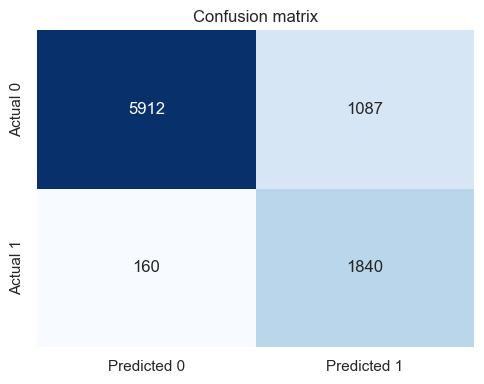

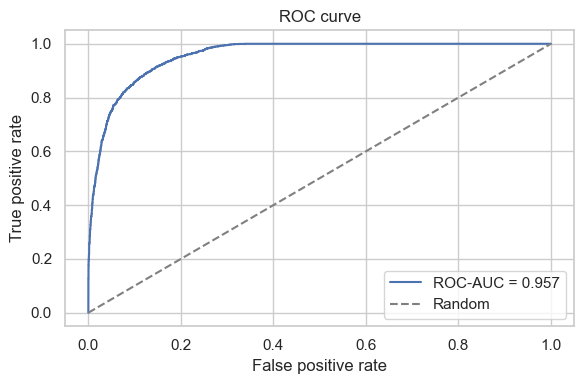

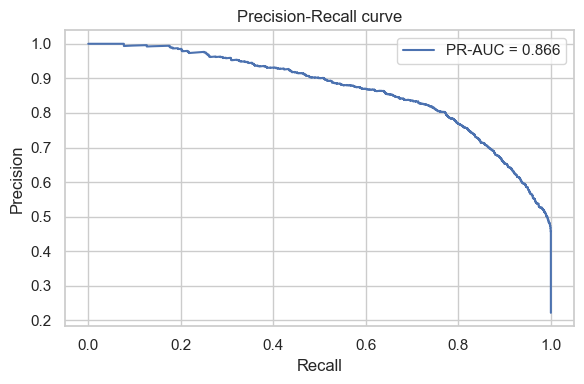

Accuracy is useful but incomplete here because class 0 is much more common than class 1.
In a loan-status setting, recall can be important when missing risky positive cases is costly, while precision matters when false alarms create unnecessary review burden.


In [11]:
y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

final_metrics = collect_binary_metrics(y_test, y_pred, y_proba)
final_metrics_df = pd.DataFrame([final_metrics]).T.rename(columns={0: "score"})
final_metrics_df.to_csv(OUTPUT_DIR / "final_test_metrics.csv")

display(final_metrics_df)

classification_report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
(REPORT_DIR / "classification_report.txt").write_text(classification_report_text, encoding="utf-8")

print("Classification report:")
print(classification_report_text)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Confusion matrix")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, label=f"ROC-AUC = {final_metrics['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC curve")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(pr_recall, pr_precision, label=f"PR-AUC = {final_metrics['pr_auc']:.3f}")
ax.set_title("Precision-Recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("Accuracy is useful but incomplete here because class 0 is much more common than class 1.")
print("In a loan-status setting, recall can be important when missing risky positive cases is costly, while precision matters when false alarms create unnecessary review burden.")


## 12. Save and Load the Complete Pipeline


In [12]:
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(final_pipeline, MODEL_PATH)
loaded_pipeline = joblib.load(MODEL_PATH)

X_test_sample = X_test.iloc[:25].copy()
original_preds = final_pipeline.predict(X_test_sample)
loaded_preds = loaded_pipeline.predict(X_test_sample)
predictions_match = bool(np.array_equal(original_preds, loaded_preds))

original_proba = final_pipeline.predict_proba(X_test_sample)[:, 1]
loaded_proba = loaded_pipeline.predict_proba(X_test_sample)[:, 1]
probabilities_match = bool(np.allclose(original_proba, loaded_proba))

assert predictions_match, "Loaded pipeline predictions do not match original predictions."
assert probabilities_match, "Loaded pipeline probabilities do not match original probabilities."

persistence_result = {
    "model_path": str(MODEL_PATH),
    "sample_size": len(X_test_sample),
    "predictions_match": predictions_match,
    "probabilities_match": probabilities_match,
}

pd.DataFrame([persistence_result]).to_csv(OUTPUT_DIR / "persistence_verification.csv", index=False)
display(pd.DataFrame([persistence_result]))
print("Pipeline save/load verification passed.")


,model_path,sample_size,predictions_match,probabilities_match
0,models\loan_status_pipeline.joblib,25,True,True


Pipeline save/load verification passed.


In this section I first created the `models` folder using `MODEL_DIR.mkdir(exist_ok=True)`.
Then I saved the complete trained pipeline in `MODEL_PATH` with `joblib.dump(final_pipeline, MODEL_PATH)`.
After that I loaded it again using `joblib.load(MODEL_PATH)` as `loaded_pipeline`.
To check that loading worked correctly I used both pipelines to predict on a small sample from `X_test`.
Finally I compared their predictions and probabilities to make sure the saved and loaded pipelines give the same results.
